1. total parameters=10*784+10=7850

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import torch.utils.data as data


torch.manual_seed(1337)
np.random.seed(1337)
random.seed(1337)

In [30]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [31]:
def preprocess_data(dataset):
    data = (dataset.data / 255.0) - 0.5
    flattened_data = data.view(data.shape[0], -1)
    targets = dataset.targets
    return flattened_data, targets

x_train, y_train = preprocess_data(trainset)
x_test, y_test = preprocess_data(testset)

In [32]:
def parameters(k,m):
    first_layer=784*m
    hidden_layer=(k-1)*(m*m+m)
    output_layer=m*10+10
    total=first_layer+hidden_layer+output_layer
    return total


In [33]:
def m_P(P,k):
    a=k-1
    b=k+784
    c=10-P
    if a==0:
        m=(P-10)/b
    else:
        if b**2-4*a*c<0:
            return None
        m=(-b+(b**2-4*a*c)**.5)/2/a
    return m if m>=1 else None


k range is found in this function. If k_P is not an integer, it's floored. As shown in a later graph, although k_max could get very large, loss already converges near k=20, so a further k isn't necessary.
In theory, P>=parameters(k,1)=802+2k, so k_max=(P-802)/2. for minimum case where k=1, m=floor((P-10)/794)>=1

In [34]:

def find_k_range(P,kMax):
    ks=[]
    for k in range(kMax+1):
        m=m_P(P,k)
        if m is not None:
            ks.append((k,m))
    if not ks:
        return None,None,[]
    return ks[0][0],ks[-1][0],ks
    #k min, k max, possible k list


In [ ]:
def iecreasingNetwork(P,k):
    base_size=int(np.sqrt(P/k/784))
    sizes=int(base_size*(.3*i+1)for i in range(k+1))
    return sizes

In [ ]:
def decreasingNetwork(P,k):
    remaining_params=P-10
    sizes=[]
    decrease_ratio=sum([1/(i+1) for i in range(k+1)])
    for i in range(k+1):
        if i==0:
            width=int((remaining_params*(1/(i+1))/decrease_ratio)/784)
        else:
            prev_width=sizes[-1]
            width=int(sizes[-1]*.7)
        sizes.append(max(10,width))
        
    return sizes

In [35]:
class Flexible(nn.Module):
    def __init__(self,k,m):
        super().__init__()
        self.layers=nn.ModuleList()
        self.layers.append(nn.Linear(784,m))
        for i in range(k-1):
            self.layers.append(nn.Linear(m,m))
        self.layers.append(nn.Linear(m,10))
        self.activation=nn.Tanh()
        self.k=k
        self.m=m

    def forward(self, x):
        for layer in self.layers[:-1]:
            x=self.activation(layer(x))
        return self.layers[-1](x)

In [36]:
def train_network(k,m,epochs=20,lr=.01):

    model=Flexible(k,m)
    
    loss_function=nn.CrossEntropyLoss()
    optimizer=optim.SGD(model.parameters(),lr=lr)

    train_dataset = data.TensorDataset(x_train, y_train)
    
    batch_size = 1024
    
    train_loader = data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

    train_losses=[]
    test_losses=[]

    for epoch in range(epochs):
        model.train()
        total_loss=0
        
        for x_batch, y_batch in train_loader:
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        train_losses.append(total_loss/len(train_loader))
            

        model.eval()
        with torch.no_grad():
            logits = model(x_test)
            test_loss=loss_function(logits,y_test)
            test_losses.append(test_loss)
    return train_losses[-1],test_losses[-1]

In [37]:
test_P=[1e4,5e4,1e5]
colors=['red','green','blue']
for P in test_P:
    k_min,k_max,ks=find_k_range(P,50)
    print(f'P={P}, k min={k_min},k max={k_max}')
    print(ks)


P=10000.0, k min=0,k max=50
[(0, 12.956466880122093), (1, 12.726114649681529), (2, 12.510789005668755), (3, 12.308753703354881), (4, 12.118555620574986), (5, 11.93896621413326), (6, 11.76893741803966), (7, 11.607567895465223), (8, 11.454076849370049), (9, 11.307783441511916), (10, 11.168090433925606), (11, 11.034471051690593), (12, 10.906458332872468), (13, 10.783636419995256), (14, 10.665633382422183), (15, 10.552115257090302), (16, 10.442781067180182), (17, 10.337358631984664), (18, 10.23560102162553), (19, 10.137283540953483), (20, 10.042201150502557), (21, 9.950166250579565), (22, 9.86100676877254), (23, 9.774564502326019), (24, 9.690693675668577), (25, 9.609259680421834), (26, 9.530137970869882), (27, 9.453213092427028), (28, 9.378377824341491), (29, 9.30553242089139), (30, 9.234583937805084), (31, 9.165445632678106), (32, 9.098036429847966), (33, 9.032280441592892), (34, 8.968106538693453), (35, 8.905447964379485), (36, 8.844241986512555), (37, 8.784429583553377), (38, 8.72595516

k=0,m=13,params=10,150
train loss: 1.0010937987747839 test loss: 0.9688324332237244
k=1,m=13,params=10,332
train loss: 0.9406858985706911 test loss: 0.9076048135757446
k=2,m=13,params=10,514
train loss: 1.3768063238111592 test loss: 1.3354895114898682
k=3,m=12,params=9,850
train loss: 1.667532448041237 test loss: 1.6458173990249634
k=4,m=12,params=10,006
train loss: 2.1481807676412292 test loss: 2.1231069564819336
k=5,m=12,params=10,162
train loss: 2.0124621068016957 test loss: 1.9948651790618896
k=6,m=12,params=10,318
train loss: 2.3013476072731667 test loss: 2.301408052444458
k=7,m=12,params=10,474
train loss: 2.301225460181802 test loss: 2.3008217811584473
k=8,m=11,params=9,668
train loss: 2.3021196308782543 test loss: 2.3021891117095947
k=9,m=11,params=9,800
train loss: 2.301938982333167 test loss: 2.30197811126709
k=10,m=11,params=9,932
train loss: 2.3034983327833274 test loss: 2.3038387298583984
k=11,m=11,params=10,064
train loss: 2.3038966938600702 test loss: 2.3034048080444336


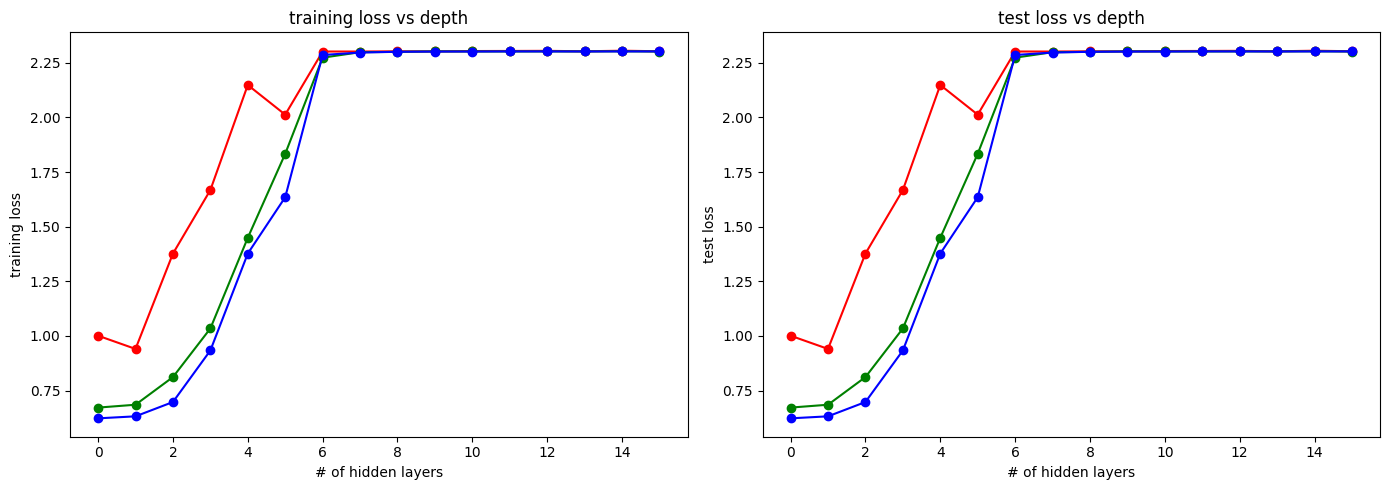

In [43]:

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.set_xlabel('# of hidden layers')
ax1.set_ylabel('training loss')
ax1.set_title('training loss vs depth')

ax2.set_xlabel('# of hidden layers')
ax2.set_ylabel('test loss')
ax2.set_title('test loss vs depth')

for P,color in zip(test_P,colors):
    k_min,k_max,ks=find_k_range(P,15)
    test_k=[]
    step=max(1,(k_max-k_min)//10)
    for k in range(k_min,k_max+1,step):
        test_k.append(k)
    if k_max not in test_k:
        test_k.append(k_max)

    ks=[]
    train_losses=[]
    test_losses=[]


    for k in test_k:
        m=int(round(m_P(P,k)))
        if m<1:
            continue
        params=parameters(k,m)
        print(f'k={k},m={m},params={params:,}')
        epochs=20
        lr=.01
        if k<=5:
            epochs=15
        else:
            lr=.005
        
        train_loss,test_loss=train_network(k,m,epochs=epochs,lr=lr)

        print(f'train loss: {train_loss} test loss: {test_loss}')

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        ks.append(k)
    
    ax1.plot(ks,train_losses,'o-',color=color,label=f'P={P:,}')
    ax2.plot(ks,train_losses,'o-',color=color,label=f'P={P:,}')

plt.tight_layout()
plt.show()



*since the legend didn't display by all methods: red: P=1e4, green: P=5e4, blue: P=1e5

In both plots, loss converges near # of k=10 with a loss around 2.25. The smallest loss appears around k=0~1, fitting the bottleneck effects near randomly guessed baselines. Deeper network reduces capacity to optimize. As P increases, minimal achievable loss decreases.